In [2]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plts

In [4]:
drinking_df = pd.read_csv("smoking_driking_dataset_Ver01.csv")
drinking_df

,sex,age,height,weight,waistline,sight_left,sight_right,hear_left,hear_right,SBP,...,LDL_chole,triglyceride,hemoglobin,urine_protein,serum_creatinine,SGOT_AST,SGOT_ALT,gamma_GTP,SMK_stat_type_cd,DRK_YN
0,Male,35,170,75,90.0,1.0,1.0,1.0,1.0,120.0,...,126.0,92.0,17.1,1.0,1.0,21.0,35.0,40.0,1.0,Y
1,Male,30,180,80,89.0,0.9,1.2,1.0,1.0,130.0,...,148.0,121.0,15.8,1.0,0.9,20.0,36.0,27.0,3.0,N
2,Male,40,165,75,91.0,1.2,1.5,1.0,1.0,120.0,...,74.0,104.0,15.8,1.0,0.9,47.0,32.0,68.0,1.0,N
3,Male,50,175,80,91.0,1.5,1.2,1.0,1.0,145.0,...,104.0,106.0,17.6,1.0,1.1,29.0,34.0,18.0,1.0,N
4,Male,50,165,60,80.0,1.0,1.2,1.0,1.0,138.0,...,117.0,104.0,13.8,1.0,0.8,19.0,12.0,25.0,1.0,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
991341,Male,45,175,80,92.1,1.5,1.5,1.0,1.0,114.0,...,125.0,132.0,15.0,1.0,1.0,26.0,36.0,27.0,1.0,N
991342,Male,35,170,75,86.0,1.0,1.5,1.0,1.0,119.0,...,84.0,45.0,15.8,1.0,1.1,14.0,17.0,15.0,1.0,N
991343,Female,40,155,50,68.0,1.0,0.7,1.0,1.0,110.0,...,77.0,157.0,14.3,1.0,0.8,30.0,27.0,17.0,3.0,Y
991344,Male,25,175,60,72.0,1.5,1.0,1.0,1.0,119.0,...,73.0,53.0,14.5,1.0,0.8,21.0,14.0,17.0,1.0,N


In [5]:
num_duplicates = drinking_df.duplicated().sum()
num_total = drinking_df.shape[0]
num_unique = num_total - num_duplicates
print(f"Prosent beholdt: {(num_unique / num_total) * 100:.10f}%")
drinking_df_unique = drinking_df.drop_duplicates()

Prosent beholdt: 99.9973773032%


In [6]:
import numpy as np
import pandas as pd

df = drinking_df_unique.copy()

cat_cols = ["sex", "SMK_stat_type_cd", "DRK_YN", "urine_protein", "hear_left", "hear_right"]
no_log = ["SMK_stat_type_cd", "urine_protein", "hemoglobin", "hear_right", "hear_left", "weight", "height", "age"]

df_log = df.copy()

def transform_with_optional_log(df, col, allow_log=True):

    global df_log

    if col not in df.columns:
        return

    data = df[col].dropna()
    if data.empty:
        return

    if col in cat_cols:
        return

    if allow_log and (data > 0).all():
        log_series = np.log10(data)     
        df_log.loc[log_series.index, col] = log_series

for col in df.columns:
    allow_log = (col not in no_log and col not in cat_cols)
    transform_with_optional_log(df, col, allow_log=allow_log)



In [7]:
import pandas as pd
import numpy as np
from scipy.stats import zscore

df = df_log.copy()

columns_to_check = [
    "age", "height", "weight", "waistline",
    "sight_left", "sight_right",
    "SBP", "DBP", "BLDS",
    "tot_chole", "HDL_chole", "LDL_chole", "triglyceride",
    "hemoglobin", "serum_creatinine", "SGOT_AST", "SGOT_ALT", "gamma_GTP",
]

# Beregn z-scores per kolonne (NaN ignoreres i sammenligningen under)
z_scores = df[columns_to_check].apply(zscore)

# Behold rader der alle valgte kolonner har |z| <= 3
mask = (np.abs(z_scores) <= 3).all(axis=1)
df_clean = df[mask].copy()

print(f"Rows before: {len(df)}, after outlier removal: {len(df_clean)}")

# df_clean er nå datasettet uten outliers etter z-score-kriteriet


Rows before: 991320, after outlier removal: 877018


In [8]:

df_clean["sex"] = df_clean["sex"].map({"Male": 0, "Female": 1})
df_clean["DRK_YN"] = df_clean["DRK_YN"].map({"N": 0, "Y": 1})

df_clean = df_clean.round(1)

df_clean.to_csv("drinking_df_encoded.csv", index=False)

print("done")

done


In [11]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# --- 1) Les data ---
df = pd.read_csv("drinking_df_encoded.csv")

# Sikre numeriske typer der mulig
for c in df.columns:
    df[c] = pd.to_numeric(df[c], errors="ignore")

# --- 2) Lag BMI og fjern height/weight ---
if {"height", "weight"}.issubset(df.columns):
    valid_h = pd.to_numeric(df["height"], errors="coerce") > 0
    df.loc[valid_h, "BMI"] = df.loc[valid_h, "weight"] / (df.loc[valid_h, "height"] / 100.0) ** 2
    df = df.drop(columns=["height", "weight"], errors="ignore")

# --- 3) Aldersgrupper → tall i [0,1] ---
bins   = [15, 24, 44, 66, 79, np.inf]              # 16–24, 25–44, 45–66, 67–79, 80+
labels = ["16-24", "25-44", "45-66", "67-79", "80+"]
if "age" in df.columns:
    age_cat = pd.cut(df["age"], bins=bins, labels=labels, include_lowest=True, right=True)
    idx_map = {lab: i for i, lab in enumerate(labels)}  # 0..4
    age_idx = age_cat.map(idx_map).astype(float)
    df["age_group_scaled"] = age_idx / (len(labels) - 1)  # → [0,1]
    df = df.drop(columns=["age"], errors="ignore")

# --- 4) Skaler alle andre numeriske kolonner til [0,1] (behold age_group_scaled som er ferdig skalert) ---
num_cols = df.select_dtypes(include=[float, int]).columns.tolist()
cols_to_scale = [c for c in num_cols if c != "age_group_scaled"]

if cols_to_scale:
    scaler = MinMaxScaler()
    df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

# --- 5) Flytt DRK_YN (target) til siste kolonne ---
if "DRK_YN" in df.columns:
    df = df[[c for c in df.columns if c != "DRK_YN"] + ["DRK_YN"]]

# --- 6) Lagre ---
out_path = "drinking_df_bmi_agegroup_scaled.csv"
df.to_csv(out_path, index=False)
print(f"✅ Done -> {out_path}")



C:\Users\aimar\AppData\Local\Temp\ipykernel_24360\1573980676.py:10: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors="ignore")


✅ Done -> drinking_df_bmi_agegroup_scaled.csv


Komponenter som kreves for forklart varians:
 - 100%: 22 komponenter
 -  90%: 12 komponenter
 -  80%: 8 komponenter


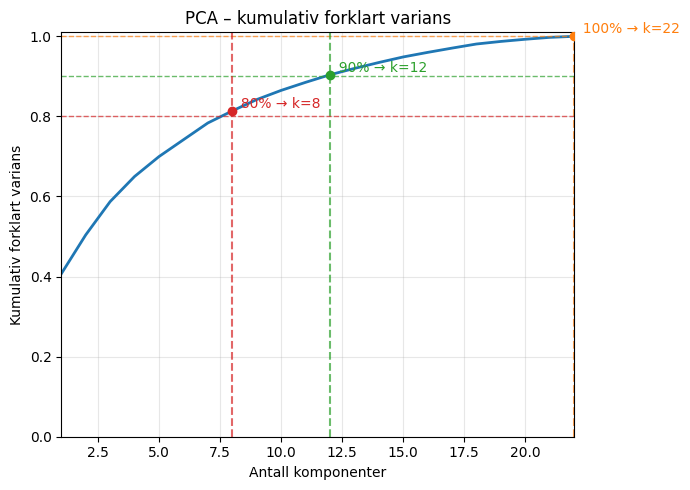

 Saved PCA-transformed data. (8 komponenter, ≈80% var) → drinking_df_pca.csv


In [12]:
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# ---- Konfig ----
CSV_IN   = "drinking_df_bmi_agegroup_scaled.csv"
CSV_OUT  = "drinking_df_pca.csv"
TARGET   = "DRK_YN"
VAR_LEVELS = [1.00, 0.90, 0.80]   # 100%, 90%, 80%
SAVE_VARIANCE = 0.80              # hvilken forklart varians skal eksporteres til CSV

# ---- Les data (forutsatt skalert) ----
df = pd.read_csv(CSV_IN)
X = df.drop(columns=[TARGET])
y = df[TARGET].values

# ---- Full PCA (alle komponenter) for å få hele kurven ----
pca_full = PCA(n_components=None, random_state=42)
X_full = pca_full.fit_transform(X)

explained = pca_full.explained_variance_ratio_
cum_explained = np.cumsum(explained)

# ---- Finn #komponenter for 100%, 90% og 80% ----
comp_counts = {}
for lvl in VAR_LEVELS:
    # searchsorted finner første indeks der kumulativ >= nivå
    k = int(np.searchsorted(cum_explained, lvl, side="left")) + 1  # +1 pga 0-indeksering → antall komponenter
    comp_counts[int(lvl*100)] = k

print("Komponenter som kreves for forklart varians:")
for pct, k in comp_counts.items():
    print(f" - {pct:>3}%: {k} komponenter")

# ---- Plott: hele kumulative varianskurven + markører ----
plt.figure(figsize=(7, 5))
plt.plot(np.arange(1, len(cum_explained)+1), cum_explained, linewidth=2)
plt.xlabel("Antall komponenter")
plt.ylabel("Kumulativ forklart varians")
plt.title("PCA – kumulativ forklart varians")

# Marker nivåene 100%, 90%, 80%
colors = {100: "C1", 90: "C2", 80: "C3"}
for pct, k in comp_counts.items():
    yval = cum_explained[k-1]
    # vertikal linje ved k, horisontal linje ved pct
    plt.axvline(k, linestyle="--", color=colors[pct], alpha=0.7)
    plt.axhline(pct/100.0, linestyle="--", color=colors[pct], alpha=0.7, linewidth=1)
    # liten annotasjon
    plt.scatter([k], [yval], color=colors[pct], zorder=3)
    plt.text(k, yval, f"  {pct}% → k={k}", va="bottom", color=colors[pct])

plt.ylim(0, 1.01)
plt.xlim(1, len(cum_explained))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ---- Lag og lagre PCA-datasett for valgt SAVE_VARIANCE ----
k_save = comp_counts[int(SAVE_VARIANCE*100)]
# Lag ny PCA med n_components = k_save og transformer
pca = PCA(n_components=k_save, random_state=42)
X_pca = pca.fit_transform(X)

pca_cols = [f"PC{i+1}" for i in range(k_save)]
df_pca = pd.DataFrame(X_pca, columns=pca_cols)
df_pca[TARGET] = y
df_pca.to_csv(CSV_OUT, index=False)

print(f" Saved PCA-transformed data. ({k_save} komponenter, ≈{int(SAVE_VARIANCE*100)}% var) → {CSV_OUT}")



In [13]:
# === Celle 1 (ALLTID lese fra PCA_CSV) ===
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Reproduserbarhet
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Filnavn
PCA_CSV = "drinking_df_pca.csv"   # må finnes; inneholder PC1..PCk + DRK_YN
NPZ_OUT = "pca_split_cache.npz"   # cache for treningscellen
TARGET = "DRK_YN"

# 1) Les alltid fra PCA_CSV (ingen ny PCA-kjøring her)
assert os.path.exists(PCA_CSV), f"Mangler {PCA_CSV} – lag denne i en separat prosess før du kjører."
df_pca = pd.read_csv(PCA_CSV)
assert TARGET in df_pca.columns, f"Mangler target-kolonne '{TARGET}' i {PCA_CSV}"

y = df_pca[TARGET].astype(int).values
X_pca = df_pca.drop(columns=[TARGET]).astype(np.float32).values

print(f"✅ Lastet PCA-data fra {PCA_CSV}: {X_pca.shape[0]} rader, {X_pca.shape[1]} komponenter.")

# 2) Stratified train/test-splitt
idx = np.arange(len(y))
idx_train, idx_test = train_test_split(
    idx, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
Xp_train, Xp_test = X_pca[idx_train], X_pca[idx_test]
y_train, y_test   = y[idx_train],      y[idx_test]

# 3) Cache til .npz for Celle 2
np.savez_compressed(
    NPZ_OUT,
    Xp_train=Xp_train, Xp_test=Xp_test,
    y_train=y_train,   y_test=y_test,
    random_state=np.array([RANDOM_STATE], dtype=np.int32)
)

print(f"💾 Cachet datasplitt til {NPZ_OUT}")
print(f"   Train: {Xp_train.shape}, Test: {Xp_test.shape}")



✅ Lastet PCA-data fra drinking_df_pca.csv: 877018 rader, 8 komponenter.
💾 Cachet datasplitt til pca_split_cache.npz
   Train: (701614, 8), Test: (175404, 8)


2025-10-25 15:32:14.858578: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow: 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ Lastet cache: Train (701614, 8), Test (175404, 8)

=== Gaussian Naive Bayes (PCA) ===
Accuracy: 0.6942
ROC AUC: 0.7475
Confusion matrix:
 [[59619 27703]
 [25936 62146]]
Classification report:
               precision    recall  f1-score   support

           0     0.6968    0.6827    0.6897     87322
           1     0.6917    0.7055    0.6985     88082

    accuracy                         0.6942    175404
   macro avg     0.6943    0.6941    0.6941    175404
weighted avg     0.6942    0.6942    0.6942    175404



I0000 00:00:1761399137.051813   93737 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6063 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2080, pci bus id: 0000:01:00.0, compute capability: 7.5


Epoch 1/5


2025-10-25 15:32:18.876049: I external/local_xla/xla/service/service.cc:163] XLA service 0x7b6c8c0044f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-10-25 15:32:18.876078: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 2080, Compute Capability 7.5
2025-10-25 15:32:18.902182: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-10-25 15:32:19.089982: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91400


  56/4386 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.6599 - auc: 0.7016 - loss: 0.6415 

I0000 00:00:1761399140.066897   93913 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


4386/4386 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - accuracy: 0.7029 - auc: 0.7694 - loss: 0.5740 - val_accuracy: 0.7000 - val_auc: 0.7713 - val_loss: 0.5776
Epoch 2/5
4386/4386 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - accuracy: 0.7058 - auc: 0.7739 - loss: 0.5690 - val_accuracy: 0.7014 - val_auc: 0.7721 - val_loss: 0.5747
Epoch 3/5
4386/4386 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.7061 - auc: 0.7747 - loss: 0.5680 - val_accuracy: 0.7025 - val_auc: 0.7726 - val_loss: 0.5735
Epoch 4/5
4386/4386 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - accuracy: 0.7067 - auc: 0.7755 - loss: 0.5672 - val_accuracy: 0.7027 - val_auc: 0.7730 - val_loss: 0.5726
Epoch 5/5
4386/4386 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.7070 - auc: 0.7761 - loss: 0.5665 - val_accuracy: 0.7037 - val_auc: 0.7740 - val_loss: 0.5711

=== Artificial Neural Network (PCA) ===
Accuracy: 0.7083
ROC AUC: 0.7787
Confusion matrix:
 [[55359 31963]
 [19199 68883]]
Classification report:
               precision    recall  f1-score   suppor

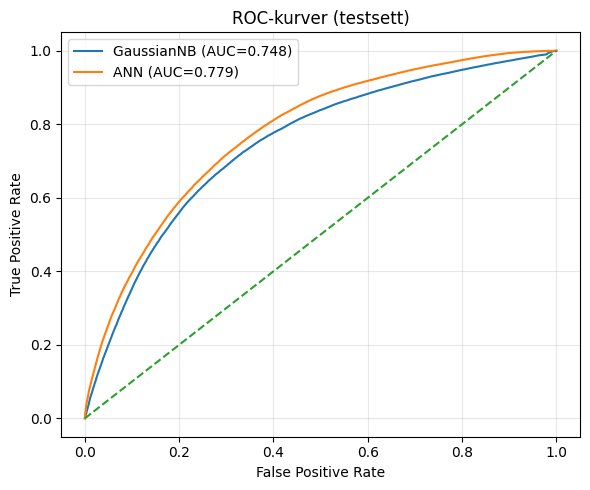

In [2]:
# === Celle 2: Tren GaussianNB + ANN, skriv ut resultater, tegn ROC-kurver ===
import numpy as np
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Reproduserbarhet
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.keras.utils.set_random_seed(RANDOM_STATE)

# 0) GPU-sjekk (valgfritt)
print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

# 1) Les cache fra celle 1
NPZ_OUT = "pca_split_cache.npz"
data = np.load(NPZ_OUT)
Xp_train, Xp_test = data["Xp_train"], data["Xp_test"]
y_train, y_test   = data["y_train"],  data["y_test"]
print(f"✅ Lastet cache: Train {Xp_train.shape}, Test {Xp_test.shape}")

# 2) Baseline: Gaussian Naive Bayes
gnb = GaussianNB()
gnb.fit(Xp_train, y_train)
gnb_prob = gnb.predict_proba(Xp_test)[:, 1]
gnb_pred = (gnb_prob >= 0.5).astype(int)

print("\n=== Gaussian Naive Bayes (PCA) ===")
print("Accuracy:", f"{accuracy_score(y_test, gnb_pred):.4f}")
print("ROC AUC:", f"{roc_auc_score(y_test, gnb_prob):.4f}")
print("Confusion matrix:\n", confusion_matrix(y_test, gnb_pred))
print("Classification report:\n", classification_report(y_test, gnb_pred, digits=4))

# 3) ANN (ReLU-skjulte lag, Sigmoid ut)
def build_ann(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(16, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(256, activation="relu"),
        layers.Dense(1, activation="sigmoid", dtype="float32"),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[keras.metrics.AUC(name="auc"), "accuracy"]
    )
    return model

ann = build_ann(Xp_train.shape[1])

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
]

history = ann.fit(
    Xp_train, y_train,
    validation_split=0.2,
    epochs=5,
    batch_size=128,
    verbose=1,
    callbacks=callbacks
)

# 4) Test-evaluering ANN
ann_prob = ann.predict(Xp_test, verbose=0).ravel()
ann_pred = (ann_prob >= 0.5).astype(int)

print("\n=== Artificial Neural Network (PCA) ===")
print("Accuracy:", f"{accuracy_score(y_test, ann_pred):.4f}")
print("ROC AUC:", f"{roc_auc_score(y_test, ann_prob):.4f}")
print("Confusion matrix:\n", confusion_matrix(y_test, ann_pred))
print("Classification report:\n", classification_report(y_test, ann_pred, digits=4))

# 5) (Valgfritt) enkel terskel-tuning basert på samme val-splitt som i fit()
val_cut = int(0.8 * len(Xp_train))
val_true = y_train[val_cut:]
val_prob = ann.predict(Xp_train[val_cut:], verbose=0).ravel()

ths = np.linspace(0.2, 0.8, 301)
accs = [accuracy_score(val_true, (val_prob >= t).astype(int)) for t in ths]
best_t = ths[int(np.argmax(accs))]
ann_pred_tuned = (ann_prob >= best_t).astype(int)
print(f"\nBest threshold from val: {best_t:.3f}")
print("Tuned test accuracy:", f"{accuracy_score(y_test, ann_pred_tuned):.4f}")

# 6) ROC-kurver (begge modeller i samme plott)
fpr_g, tpr_g, _ = roc_curve(y_test, gnb_prob)
fpr_a, tpr_a, _ = roc_curve(y_test, ann_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr_g, tpr_g, label=f"GaussianNB (AUC={roc_auc_score(y_test, gnb_prob):.3f})")
plt.plot(fpr_a, tpr_a, label=f"ANN (AUC={roc_auc_score(y_test, ann_prob):.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-kurver (testsett)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


TensorFlow: 2.20.0
GPUs: []
✅ Lastet cache: Train (701614, 8), Test (175404, 8)
Epoch 1/40
4386/4386 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.7032 - auc: 0.7699 - loss: 0.5734 - val_accuracy: 0.7007 - val_auc: 0.7714 - val_loss: 0.5762
Epoch 2/40
4386/4386 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.7061 - auc: 0.7740 - loss: 0.5689 - val_accuracy: 0.7025 - val_auc: 0.7723 - val_loss: 0.5737
Epoch 3/40
4386/4386 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.7072 - auc: 0.7750 - loss: 0.5679 - val_accuracy: 0.7036 - val_auc: 0.7731 - val_loss: 0.5724
Epoch 4/40
4386/4386 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.7074 - auc: 0.7758 - loss: 0.5671 - val_accuracy: 0.7041 - val_auc: 0.7737 - val_loss: 0.5711
Epoch 5/40
4386/4386 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.7081 - auc: 0.7765 - loss: 0.5664 - val_accuracy: 0.7052 - val_auc: 0.7743 - val_loss: 0.5701
Epoch 6/40
4386/4386 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.7087 - auc: 0.7772 - loss: 0.5658 - val_a

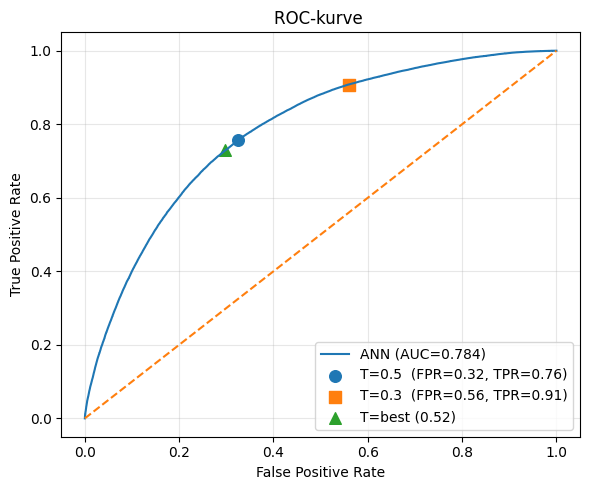

In [ ]:
# === Celle 2: Tren ANN, skriv ut resultater, tegn ROC med terskelmarkører ===
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_score, recall_score, f1_score
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Reproduserbarhet
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.keras.utils.set_random_seed(RANDOM_STATE)

# 0) GPU-sjekk (valgfritt)
print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

# 1) Les cache fra celle 1
NPZ_OUT = "pca_split_cache.npz"
data = np.load(NPZ_OUT)
Xp_train, Xp_test = data["Xp_train"], data["Xp_test"]
y_train, y_test   = data["y_train"],  data["y_test"]
print(f"✅ Lastet cache: Train {Xp_train.shape}, Test {Xp_test.shape}")

# 2) Bygg og tren ANN (ReLU-skjulte lag, Sigmoid ut)
def build_ann(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(16, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(256, activation="relu"),
        layers.Dense(1, activation="sigmoid", dtype="float32"),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[keras.metrics.AUC(name="auc"), "accuracy"]
    )
    return model

ann = build_ann(Xp_train.shape[1])

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
]

history = ann.fit(
    Xp_train, y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=128,
    verbose=1,
    callbacks=callbacks
)

# 3) Test-evaluering (sannsynligheter + standard terskel 0.5)
ann_prob = ann.predict(Xp_test, verbose=0).ravel()

def metrics_at_threshold(y_true, prob, thr):
    pred = (prob >= thr).astype(int)
    acc = accuracy_score(y_true, pred)
    auc = roc_auc_score(y_true, prob)
    prec = precision_score(y_true, pred, zero_division=0)
    rec = recall_score(y_true, pred, zero_division=0)
    f1 = f1_score(y_true, pred, zero_division=0)
    cm = confusion_matrix(y_true, pred)
    # FPR/TPR for markør i ROC
    tn, fp, fn, tp = cm.ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    return {"thr": thr, "acc": acc, "auc": auc, "prec": prec, "rec": rec, "f1": f1,
            "cm": cm, "fpr": fpr, "tpr": tpr}

# Standard terskler
res_05 = metrics_at_threshold(y_test, ann_prob, 0.5)
res_03 = metrics_at_threshold(y_test, ann_prob, 0.3)

print("\n=== ANN (PCA) @ threshold = 0.5 ===")
print(f"Accuracy: {res_05['acc']:.4f} | ROC AUC: {res_05['auc']:.4f} | Precision: {res_05['prec']:.4f} | Recall: {res_05['rec']:.4f} | F1: {res_05['f1']:.4f}")
print("Confusion matrix:\n", res_05["cm"])
print("Classification report:\n", classification_report(y_test, (ann_prob >= 0.5).astype(int), digits=4))

print("\n=== ANN (PCA) @ threshold = 0.3 ===")
print(f"Accuracy: {res_03['acc']:.4f} | ROC AUC: {res_03['auc']:.4f} | Precision: {res_03['prec']:.4f} | Recall: {res_03['rec']:.4f} | F1: {res_03['f1']:.4f}")
print("Confusion matrix:\n", res_03["cm"])
print("Classification report:\n", classification_report(y_test, (ann_prob >= 0.3).astype(int), digits=4))

# 4) (Valgfritt) enkel terskel-tuning basert på samme val-splitt som i fit()
val_cut = int(0.8 * len(Xp_train))
val_true = y_train[val_cut:]
val_prob = ann.predict(Xp_train[val_cut:], verbose=0).ravel()

ths = np.linspace(0.2, 0.8, 301)
accs = [accuracy_score(val_true, (val_prob >= t).astype(int)) for t in ths]
best_t = ths[int(np.argmax(accs))]
res_best = metrics_at_threshold(y_test, ann_prob, best_t)

print(f"\nBest threshold from val: {best_t:.3f}")
print(f"Tuned test accuracy: {res_best['acc']:.4f} | Precision: {res_best['prec']:.4f} | Recall: {res_best['rec']:.4f} | F1: {res_best['f1']:.4f}")

# 5) ROC-kurve + markører for terskel 0.5 og 0.3
fpr, tpr, _ = roc_curve(y_test, ann_prob)
auc_val = roc_auc_score(y_test, ann_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ANN (AUC={auc_val:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

# Marker operasjonspunkter
plt.scatter(res_05["fpr"], res_05["tpr"], s=70, marker="o", label=f"T=0.5  (FPR={res_05['fpr']:.2f}, TPR={res_05['tpr']:.2f})")
plt.scatter(res_03["fpr"], res_03["tpr"], s=70, marker="s", label=f"T=0.3  (FPR={res_03['fpr']:.2f}, TPR={res_03['tpr']:.2f})")
plt.scatter(res_best["fpr"], res_best["tpr"], s=70, marker="^", label=f"T=best ({best_t:.2f})")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-kurve ")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [345]:
# Lagre treningshistorikk til CSV for videre bruk
import pandas as pd

hist_df = pd.DataFrame(history.history)
hist_df.to_csv("training_log.csv", index=False)
print("✅ Lagret treningshistorikk til training_log.csv")


NameError: name 'history' is not defined

In [ ]:
### Oppgave 8:

In [346]:
# Load all health checkup datasets from 2016 to 2020
df_2016 = pd.read_csv("health_checkup_2016.csv")
df_2017 = pd.read_csv("health_checkup_2017.csv")
df_2018 = pd.read_csv("health_checkup_2018.csv")
df_2019 = pd.read_csv("health_checkup_2019.csv")
df_2020 = pd.read_csv("health_checkup_2020.csv")

print(f"2016 shape: {df_2016.shape}")
print(f"2017 shape: {df_2017.shape}")
print(f"2018 shape: {df_2018.shape}")
print(f"2019 shape: {df_2019.shape}")
print(f"2020 shape: {df_2020.shape}")

# Combine all years
df_combined = pd.concat([df_2016, df_2017, df_2018, df_2019, df_2020], ignore_index=True)
print(f"\nCombined 2016-2020 shape: {df_combined.shape}")

# Remove duplicates
num_duplicates = df_combined.duplicated().sum()
num_total = df_combined.shape[0]
num_unique = num_total - num_duplicates
print(f"Duplicates found: {num_duplicates} ({(num_duplicates/num_total)*100:.2f}%)")

df_2020_unique = df_combined.drop_duplicates()
print(f"After deduplication: {df_2020_unique.shape}")
print(f"Total samples retained: {len(df_2020_unique):,}")

2016 shape: (1000000, 34)
2017 shape: (1000000, 34)
2018 shape: (1000000, 34)
2019 shape: (1063619, 31)
2020 shape: (1000000, 31)

Combined 2016-2020 shape: (5063619, 34)
Duplicates found: 63618 (1.26%)
After deduplication: (5000001, 34)
Total samples retained: 5,000,001


In [347]:
df_combined

,YEAR,IDV_ID,SEX,AGE_GROUP,AREA_CODE,HEIGHT,WEIGHT,WAIST,SIGHT_LEFT,SIGHT_RIGHT,...,GAMMA_GTP,SMK_STAT,DRK_YN,HCHK_CE_IN,CRS_YN,TTH_MSS_YN,ODT_TRB_YN,WSDM_DIS_YN,TTR_YN,DATE
0,2016,1,1,10,27,175.0,75.0,86.0,1.0,1.2,...,45.0,3.0,NaN,N,NaN,NaN,NaN,NaN,NaN,2017-12-19
1,2016,2,2,11,41,160.0,65.0,85.0,1.5,1.2,...,19.0,1.0,NaN,N,NaN,NaN,NaN,NaN,NaN,2017-12-19
2,2016,3,2,11,43,150.0,55.0,80.0,1.5,1.5,...,64.0,1.0,NaN,N,NaN,NaN,NaN,NaN,NaN,2017-12-19
3,2016,4,1,12,48,175.0,70.0,85.0,1.2,1.2,...,69.0,2.0,NaN,Y,NaN,NaN,NaN,NaN,Y,2017-12-19
4,2016,5,2,6,11,160.0,50.0,67.0,0.4,0.5,...,20.0,1.0,NaN,N,NaN,NaN,NaN,NaN,NaN,2017-12-19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5063614,2020,999996,2,13,41,145.0,55.0,81.0,0.9,1.0,...,18.0,1.0,0.0,0,NaN,NaN,NaN,NaN,NaN,2021-12-29
5063615,2020,999997,2,12,26,160.0,55.0,76.5,1.5,1.5,...,19.0,1.0,1.0,0,NaN,NaN,NaN,NaN,NaN,2021-12-29
5063616,2020,999998,1,9,48,175.0,70.0,85.0,1.2,1.2,...,17.0,1.0,1.0,0,NaN,NaN,NaN,NaN,NaN,2021-12-29
5063617,2020,999999,2,9,48,160.0,70.0,91.0,0.6,0.5,...,13.0,1.0,0.0,0,NaN,NaN,NaN,NaN,NaN,2021-12-29


In [348]:
column_mapping = {
    "REAL_AGE": "age",
    "AGE_GROUP": "age_group",
    "HEIGHT": "height",
    "WEIGHT": "weight",
    "SIGHT_LEFT": "sight_left",
    "SIGHT_RIGHT": "sight_right",
    "HEAR_LEFT": "hear_left",
    "HEAR_RIGHT": "hear_right",
    "SBP": "SBP",
    "DBP": "DBP",
    "BLDS": "BLDS",
    "TOT_CHOL": "tot_chole",
    "HDL_CHOL": "HDL_chole",
    "LDL_CHOL": "LDL_chole",
    "TRIGLYCERIDE": "triglyceride",
    "URINE_PROTEIN": "urine_protein",
    "GAMMA_GTP": "gamma_GTP",
    "SMK_STAT": "SMK_stat_type_cd",
    "DRK_YN": "DRK_YN",
    "WAIST": "waistline",
    "SEX": "sex"
}

df_2020_renamed = df_2020_unique.rename(columns=column_mapping)

if "age_group" in df_2020_renamed.columns and "age" not in df_2020_renamed.columns:
    age_group_to_age = {
        1: 2, 2: 7, 3: 12, 4: 17, 5: 22,
        6: 27, 7: 32, 8: 37, 9: 42, 10: 47,
        11: 52, 12: 57, 13: 62, 14: 67, 15: 72,
        16: 77, 17: 82, 18: 87
    }
    df_2020_renamed["age"] = df_2020_renamed["age_group"].map(age_group_to_age)
    df_2020_renamed = df_2020_renamed.drop(columns=["age_group"])

original_cols = pd.read_csv("smoking_driking_dataset_Ver01.csv").columns.tolist()
common_cols = [c for c in original_cols if c in df_2020_renamed.columns]
df_2020_renamed = df_2020_renamed[common_cols]

print(f"Columns mapped: {df_2020_renamed.shape}")
print(f"Common columns: {len(common_cols)}")
for c in common_cols:
    print(f" - {c}")

Columns mapped: (5000001, 15)
Common columns: 15
 - sex
 - age
 - height
 - weight
 - waistline
 - sight_left
 - sight_right
 - hear_left
 - hear_right
 - BLDS
 - triglyceride
 - SGOT_AST
 - gamma_GTP
 - SMK_stat_type_cd
 - DRK_YN


In [349]:
nan_counts = df_2020_renamed.isna().sum()
nan_counts_filtered = nan_counts[nan_counts > 0].sort_values(ascending=False)

print(f"Features with NaN values:")
print(nan_counts_filtered)
print(f"\nTotal features with NaN: {len(nan_counts_filtered)}/{len(df_2020_renamed.columns)}")

Features with NaN values:
triglyceride        1931475
DRK_YN              1710757
BLDS                  19130
gamma_GTP             19127
SGOT_AST              19112
waistline              1384
sight_right            1194
sight_left             1188
SMK_stat_type_cd       1100
hear_right             1047
hear_left              1044
weight                  897
height                  897
dtype: int64

Total features with NaN: 13/15


In [350]:
df_2020_renamed = df_2020_renamed.drop(columns=["triglyceride"], errors="ignore")
print(f"Removed triglyceride. New shape: {df_2020_renamed.shape}")

Removed triglyceride. New shape: (5000001, 14)


In [351]:
before_nan = len(df_2020_renamed)
df_2020_renamed = df_2020_renamed.dropna()
after_nan = len(df_2020_renamed)
removed_nan = before_nan - after_nan

print(f"Before NaN removal: {before_nan}")
print(f"After NaN removal: {after_nan}")
print(f"Rows removed: {removed_nan} ({(removed_nan/before_nan)*100:.2f}%)")

Before NaN removal: 5000001
After NaN removal: 3277031
Rows removed: 1722970 (34.46%)


In [352]:
df = df_2020_renamed.copy()
df_2020_log = df.copy()

cat_cols = ["sex", "SMK_stat_type_cd", "DRK_YN", "urine_protein", "hear_left", "hear_right"]
no_log = ["SMK_stat_type_cd", "urine_protein", "hemoglobin", "hear_right", "hear_left", "weight", "height", "age"]

for col in df.columns:
    if col in cat_cols:
        continue
    data = df[col].dropna()
    if data.empty:
        continue
    allow_log = (col not in no_log and col not in cat_cols)
    if allow_log and (data > 0).all():
        log_series = np.log10(data)
        df_2020_log.loc[log_series.index, col] = log_series

print(f"Log transform complete")

Log transform complete


In [353]:
from scipy.stats import zscore

df = df_2020_log.copy()
columns_to_check = [
    "age", "height", "weight", "waistline",
    "sight_left", "sight_right","BLDS" , "gamma_GTP",
]

z_scores = df[columns_to_check].apply(zscore)
mask = (np.abs(z_scores) <= 3).all(axis=1)
df_2020_clean = df[mask].copy()

print(f"Before: {len(df)}, After outlier removal: {len(df_2020_clean)}")

Before: 3277031, After outlier removal: 3037801


In [354]:
df_2020_clean["sex"] = df_2020_clean["sex"].map({1: 0, 2: 1})

print(f"DRK_YN unique values: {df_2020_clean['DRK_YN'].unique()}")
df_2020_clean["DRK_YN"] = df_2020_clean["DRK_YN"].map({
    "N": 0, 
    "Y": 1, 
    0.0: 0, 
    1.0: 1
})
df_2020_clean = df_2020_clean.round(1)

print("Encoding complete")

print(df_2020_clean.isna().sum())
print(f"DRK_YN unique values: {df_2020_clean['DRK_YN'].unique()}")

DRK_YN unique values: ['Y' 'N' 1.0 0.0]
Encoding complete
sex                 0
age                 0
height              0
weight              0
waistline           0
sight_left          0
sight_right         0
hear_left           0
hear_right          0
BLDS                0
SGOT_AST            0
gamma_GTP           0
SMK_stat_type_cd    0
DRK_YN              0
dtype: int64
DRK_YN unique values: [1 0]


In [330]:
from sklearn.preprocessing import MinMaxScaler

df = df_2020_clean.copy()

for c in df.columns:
    df[c] = pd.to_numeric(df[c], errors="ignore")

if {"height", "weight"}.issubset(df.columns):
    valid_h = pd.to_numeric(df["height"], errors="coerce") > 0
    df.loc[valid_h, "BMI"] = df.loc[valid_h, "weight"] / (df.loc[valid_h, "height"] / 100.0) ** 2
    df = df.drop(columns=["height", "weight"], errors="ignore")

bins = [15, 24, 44, 66, 79, np.inf]
labels = ["16-24", "25-44", "45-66", "67-79", "80+"]
if "age" in df.columns:
    age_cat = pd.cut(df["age"], bins=bins, labels=labels, include_lowest=True, right=True)
    idx_map = {lab: i for i, lab in enumerate(labels)}
    age_idx = age_cat.map(idx_map).astype(float)
    df["age_group_scaled"] = age_idx / (len(labels) - 1)
    df = df.drop(columns=["age"], errors="ignore")

num_cols = df.select_dtypes(include=[float, int]).columns.tolist()
cols_to_scale = [c for c in num_cols if c != "age_group_scaled"]

if cols_to_scale:
    scaler = MinMaxScaler()
    df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

if "DRK_YN" in df.columns:
    df = df[[c for c in df.columns if c != "DRK_YN"] + ["DRK_YN"]]

df_2020_processed = df.copy()
print(f"Scaled dataset shape: {df_2020_processed.shape}")

C:\Users\aimar\AppData\Local\Temp\ipykernel_41904\1057228376.py:6: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors="ignore")


Scaled dataset shape: (3038328, 12)


In [331]:
from sklearn.decomposition import PCA

X_2020 = df_2020_processed.drop(columns=["DRK_YN"])
y_2020 = df_2020_processed["DRK_YN"].values

pca = PCA(n_components=8, random_state=42)
X_2020_pca = pca.fit_transform(X_2020)

pca_cols = [f"PC{i+1}" for i in range(8)]
df_2020_pca = pd.DataFrame(X_2020_pca, columns=pca_cols)
df_2020_pca["DRK_YN"] = y_2020

print(f"PCA complete: {df_2020_pca.shape}")

PCA complete: (3038328, 9)


In [332]:
df_2020_pca.to_csv("health_checkup_2020_pca.csv", index=False)
print(f"Saved 2020 PCA dataset to: health_checkup_2020_pca.csv")
print(f"Shape: {df_2020_pca.shape}")

Saved 2020 PCA dataset to: health_checkup_2020_pca.csv
Shape: (3038328, 9)


In [333]:
print(df_2020_pca.isna().sum())

PC1       0
PC2       0
PC3       0
PC4       0
PC5       0
PC6       0
PC7       0
PC8       0
DRK_YN    0
dtype: int64


### Transfer Learning Dataset Analysis

In [334]:
# Load and compare datasets
df_transfer = pd.read_csv("health_checkup_2020_pca.csv")
df_original = pd.read_csv("drinking_df_pca.csv")

print("="*60)
print("DATASET COMPARISON")
print("="*60)
print(f"\n{'Metric':<30} {'Health Checkup':<20} {'Original':<15}")
print("-"*60)
print(f"{'Total Samples':<30} {len(df_transfer):>15,}     {len(df_original):>12,}")
print(f"{'Features (PCs)':<30} {df_transfer.shape[1]-1:>15}     {df_original.shape[1]-1:>12}")
print(f"{'Drinkers (Y=1)':<30} {(df_transfer['DRK_YN']==1).sum():>15,}     {(df_original['DRK_YN']==1).sum():>12,}")
print(f"{'Non-Drinkers (Y=0)':<30} {(df_transfer['DRK_YN']==0).sum():>15,}     {(df_original['DRK_YN']==0).sum():>12,}")
print(f"{'Class Balance (%Y)':<30} {(df_transfer['DRK_YN']==1).mean()*100:>14.1f}%     {(df_original['DRK_YN']==1).mean()*100:>11.1f}%")

size_ratio = len(df_transfer) / len(df_original)
print(f"\nTransfer dataset is {size_ratio:.1f}x larger ({len(df_transfer)-len(df_original):,} more samples)")

print("\n" + "="*60)
print("TRANSFER DATASET STATISTICS")
print("="*60)
feature_cols = [col for col in df_transfer.columns if col != 'DRK_YN']
stats = df_transfer[feature_cols].describe().T[['mean', 'std', 'min', 'max']]
print(stats.round(3).to_string())
print("="*60)

DATASET COMPARISON

Metric                         Health Checkup       Original       
------------------------------------------------------------
Total Samples                        3,038,328          877,018
Features (PCs)                               8                8
Drinkers (Y=1)                       2,207,926          440,409
Non-Drinkers (Y=0)                     830,402          436,609
Class Balance (%Y)                       72.7%            50.2%

Transfer dataset is 3.5x larger (2,161,310 more samples)

TRANSFER DATASET STATISTICS
     mean    std    min    max
PC1  -0.0  0.512 -0.683  0.764
PC2  -0.0  0.258 -1.136  0.836
PC3  -0.0  0.200 -0.959  1.079
PC4   0.0  0.166 -0.938  0.856
PC5  -0.0  0.153 -0.781  0.854
PC6   0.0  0.136 -0.663  0.838
PC7  -0.0  0.101 -0.459  1.364
PC8   0.0  0.101 -0.564  1.121


In [335]:
# === BALANCE CLASSES (50-50 split) ===
print("\n" + "="*60)
print("CLASS BALANCING")
print("="*60)

# Check current distribution
class_counts = df_transfer['DRK_YN'].value_counts()
print(f"\nBefore balancing:")
print(f"  Class 0 (Non-drinkers): {class_counts[0]:,}")
print(f"  Class 1 (Drinkers): {class_counts[1]:,}")
print(f"  Ratio: {class_counts[1]/class_counts[0]:.3f}")

# Find minority class size
minority_class = class_counts.min()
print(f"\nTarget size per class: {minority_class:,}")

# Undersample majority class to match minority class
df_class_0 = df_transfer[df_transfer['DRK_YN'] == 0]
df_class_1 = df_transfer[df_transfer['DRK_YN'] == 1]

# Sample from each class
np.random.seed(42)
df_class_0_sampled = df_class_0.sample(n=minority_class, random_state=42)
df_class_1_sampled = df_class_1.sample(n=minority_class, random_state=42)

# Combine and shuffle
df_transfer = pd.concat([df_class_0_sampled, df_class_1_sampled], axis=0)
df_transfer = df_transfer.sample(frac=1, random_state=42).reset_index(drop=True)

# Verify balance
class_counts_after = df_transfer['DRK_YN'].value_counts()
print(f"\nAfter balancing:")
print(f"  Class 0 (Non-drinkers): {class_counts_after[0]:,}")
print(f"  Class 1 (Drinkers): {class_counts_after[1]:,}")
print(f"  Ratio: {class_counts_after[1]/class_counts_after[0]:.3f}")
print(f"  Total samples: {len(df_transfer):,}")
print("="*60)
df_transfer.to_csv("health_checkup_2020_pca_balanced.csv", index=False)


CLASS BALANCING

Before balancing:
  Class 0 (Non-drinkers): 830,402
  Class 1 (Drinkers): 2,207,926
  Ratio: 2.659

Target size per class: 830,402

After balancing:
  Class 0 (Non-drinkers): 830,402
  Class 1 (Drinkers): 830,402
  Ratio: 1.000
  Total samples: 1,660,804


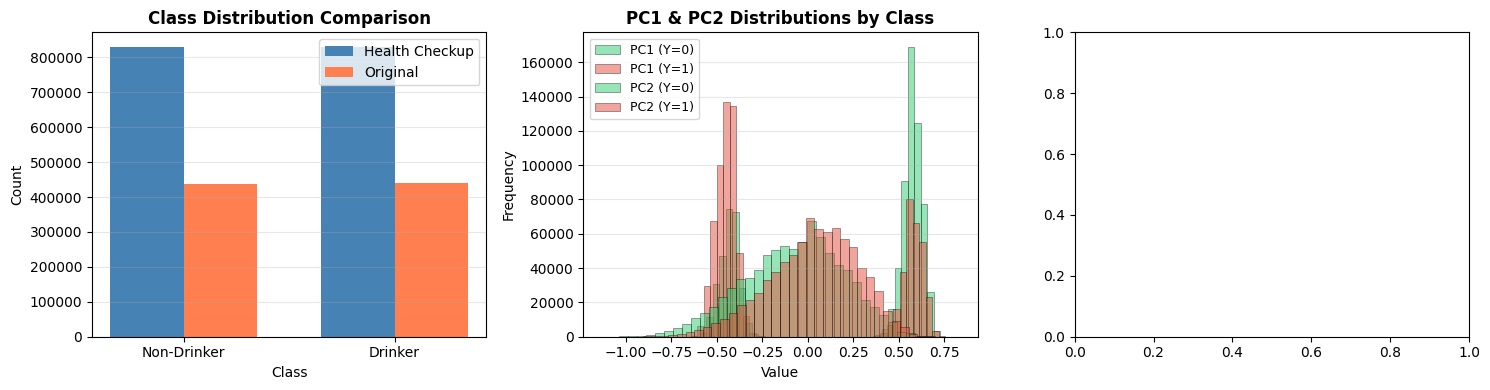

Visualization complete


In [336]:
# Visualizations
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Class distribution comparison
target_counts_transfer = df_transfer['DRK_YN'].value_counts().sort_index()
target_counts_original = df_original['DRK_YN'].value_counts().sort_index()

x = np.arange(2)
width = 0.35
axes[0].bar(x - width/2, target_counts_transfer, width, label='Health Checkup', color='steelblue')
axes[0].bar(x + width/2, target_counts_original, width, label='Original', color='coral')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].set_title('Class Distribution Comparison', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['Non-Drinker', 'Drinker'])
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# 2. PC distributions (first 4 components)
colors_class = {0: '#2ecc71', 1: '#e74c3c'}
for i, pc in enumerate(['PC1', 'PC2']):
    for cls in [0, 1]:
        data = df_transfer[df_transfer['DRK_YN'] == cls][pc]
        axes[1].hist(data, bins=40, alpha=0.5, label=f'{pc} (Y={cls})', 
                    color=colors_class[cls], edgecolor='black', linewidth=0.5)
axes[1].set_xlabel('Value')
axes[1].set_ylabel('Frequency')
axes[1].set_title('PC1 & PC2 Distributions by Class', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("Visualization complete")

## Transfer Learning Implementation

We'll use the larger health_checkup dataset (2019+2020 combined) to pretrain our model, then fine-tune it on the original smaller smoking_drinking dataset.

In [337]:
# === Step 1: Load both datasets (large transfer dataset + original dataset) ===
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Load large transfer learning dataset (health checkup)
df_transfer = pd.read_csv("health_checkup_2020_pca_balanced.csv")
print(f"Transfer learning dataset loaded: {df_transfer.shape}")
print(f"   Columns: {df_transfer.columns.tolist()}")

# Load original smaller dataset
df_original = pd.read_csv("drinking_df_pca.csv")
print(f"Original dataset loaded: {df_original.shape}")
print(f"   Columns: {df_original.columns.tolist()}")

# Prepare transfer dataset (for pretraining)
X_transfer = df_transfer.drop(columns=["DRK_YN"]).astype(np.float32).values
y_transfer = df_transfer["DRK_YN"].astype(int).values

# Split transfer dataset into train/val
X_transfer_train, X_transfer_val, y_transfer_train, y_transfer_val = train_test_split(
    X_transfer, y_transfer, test_size=0.2, stratify=y_transfer, random_state=RANDOM_STATE
)

print(f"\nTransfer dataset split:")
print(f"   Train: {X_transfer_train.shape}")
print(f"   Val: {X_transfer_val.shape}")

# Prepare original dataset (for fine-tuning and testing)
X_original = df_original.drop(columns=["DRK_YN"]).astype(np.float32).values
y_original = df_original["DRK_YN"].astype(int).values

# Split original dataset into train (for fine-tuning) and test (for evaluation)
X_finetune, X_test, y_finetune, y_test = train_test_split(
    X_original, y_original, test_size=0.2, stratify=y_original, random_state=RANDOM_STATE
)

print(f"\nOriginal dataset split:")
print(f"   Fine-tune: {X_finetune.shape}")
print(f"   Test: {X_test.shape}")

print(f"\nData preparation complete!")

Transfer learning dataset loaded: (1660804, 9)
   Columns: ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'DRK_YN']
Original dataset loaded: (877018, 9)
   Columns: ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'DRK_YN']

Transfer dataset split:
   Train: (1328643, 8)
   Val: (332161, 8)

Original dataset split:
   Fine-tune: (701614, 8)
   Test: (175404, 8)

Data preparation complete!


In [338]:
# === Step 2: Pretrain model on large transfer dataset ===
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.keras.utils.set_random_seed(RANDOM_STATE)

print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

# Build the same ANN architecture as before
def build_transfer_ann(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(16, activation="relu", name="hidden_1"),
        layers.Dense(64, activation="relu", name="hidden_2"),
        layers.Dense(128, activation="relu", name="hidden_3"),
        layers.Dense(256, activation="relu", name="hidden_4"),
        layers.Dense(1, activation="sigmoid", dtype="float32", name="output"),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[keras.metrics.AUC(name="auc"), "accuracy"]
    )
    return model

# Create and pretrain on large transfer dataset
pretrained_model = build_transfer_ann(X_transfer_train.shape[1])
print("\n🔧 Model architecture:")
pretrained_model.summary()

print("\nPhase 1: PRETRAINING on large health checkup dataset...")

pretrain_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss", 
        patience=5, 
        restore_best_weights=True,
        verbose=1
    )
]

pretrain_history = pretrained_model.fit(
    X_transfer_train, y_transfer_train,
    validation_data=(X_transfer_val, y_transfer_val),
    epochs=40,
    batch_size=128,
    verbose=1,
    callbacks=pretrain_callbacks
)

print(f"\nPretraining complete: Trained for {len(pretrain_history.history['loss'])} epochs")

TensorFlow: 2.20.0
GPUs: []

🔧 Model architecture:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_4 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,833 (167.32 KB)

 Trainable params: 42,833 (167.32 KB)

 Non-trainable params: 0 (0.00 B)


Phase 1: PRETRAINING on large health checkup dataset...
Epoch 1/40
10381/10381 ━━━━━━━━━━━━━━━━━━━━ 23s 2ms/step - accuracy: 0.6959 - auc: 0.7584 - loss: 0.5827 - val_accuracy: 0.6974 - val_auc: 0.7612 - val_loss: 0.5810
Epoch 2/40
10381/10381 ━━━━━━━━━━━━━━━━━━━━ 21s 2ms/step - accuracy: 0.6967 - auc: 0.7596 - loss: 0.5816 - val_accuracy: 0.6977 - val_auc: 0.7614 - val_loss: 0.5803
Epoch 3/40
10381/10381 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - accuracy: 0.6967 - auc: 0.7599 - loss: 0.5813 - val_accuracy: 0.6976 - val_auc: 0.7614 - val_loss: 0.5800
Epoch 4/40
10381/10381 ━━━━━━━━━━━━━━━━━━━━ 21s 2ms/step - accuracy: 0.6967 - auc: 0.7600 - loss: 0.5812 - val_accuracy: 0.6978 - val_auc: 0.7615 - val_loss: 0.5800
Epoch 5/40
10381/10381 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - accuracy: 0.6968 - auc: 0.7601 - loss: 0.5811 - val_accuracy: 0.6979 - val_auc: 0.7615 - val_loss: 0.5800
Epoch 6/40
10381/10381 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - accuracy: 0.6967 - auc: 0.7602 - loss: 0.5810 - val_accurac

In [339]:
# === Step 3: Fine-tune on original smaller dataset ===
print("\n🎯 Phase 2: FINE-TUNING on original smoking_drinking dataset...")

# Use the pretrained model and fine-tune on original dataset
finetune_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    )
]

finetune_history = pretrained_model.fit(
    X_finetune, y_finetune,
    validation_split=0.2,
    epochs=40,
    batch_size=128,
    verbose=1,
    callbacks=finetune_callbacks
)

print(f"\nFine-tuning complete: Trained for {len(finetune_history.history['loss'])} epochs")


🎯 Phase 2: FINE-TUNING on original smoking_drinking dataset...
Epoch 1/40
4386/4386 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.6990 - auc: 0.7644 - loss: 0.5791 - val_accuracy: 0.6997 - val_auc: 0.7659 - val_loss: 0.5778
Epoch 2/40
4386/4386 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.7039 - auc: 0.7716 - loss: 0.5716 - val_accuracy: 0.7031 - val_auc: 0.7703 - val_loss: 0.5730
Epoch 3/40
4386/4386 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.7057 - auc: 0.7737 - loss: 0.5691 - val_accuracy: 0.7040 - val_auc: 0.7713 - val_loss: 0.5721
Epoch 4/40
4386/4386 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.7063 - auc: 0.7745 - loss: 0.5683 - val_accuracy: 0.7047 - val_auc: 0.7717 - val_loss: 0.5715
Epoch 5/40
4386/4386 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.7069 - auc: 0.7750 - loss: 0.5678 - val_accuracy: 0.7051 - val_auc: 0.7721 - val_loss: 0.5711
Epoch 6/40
4386/4386 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.7074 - auc: 0.7754 - loss: 0.5674 - val_accuracy: 0.7053 

In [340]:
# === Step 4: Evaluate on test set ===
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_score, recall_score, f1_score
)

# Get predictions on test set
transfer_prob = pretrained_model.predict(X_test, verbose=0).ravel()
transfer_pred = (transfer_prob >= 0.5).astype(int)

# Calculate metrics
acc = accuracy_score(y_test, transfer_pred)
auc = roc_auc_score(y_test, transfer_prob)
prec = precision_score(y_test, transfer_pred, zero_division=0)
rec = recall_score(y_test, transfer_pred, zero_division=0)
f1 = f1_score(y_test, transfer_pred, zero_division=0)
cm = confusion_matrix(y_test, transfer_pred)

print("\n" + "="*60)
print("TRANSFER LEARNING MODEL - TEST SET RESULTS")
print("="*60)
print(f"Accuracy:  {acc:.4f}")
print(f"ROC AUC:   {auc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")
print("\nConfusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(y_test, transfer_pred, digits=4))


TRANSFER LEARNING MODEL - TEST SET RESULTS
Accuracy:  0.7166
ROC AUC:   0.7909
Precision: 0.7003
Recall:    0.7616
F1 Score:  0.7297

Confusion Matrix:
[[58611 28711]
 [20997 67085]]

Classification Report:
              precision    recall  f1-score   support

           0     0.7362    0.6712    0.7022     87322
           1     0.7003    0.7616    0.7297     88082

    accuracy                         0.7166    175404
   macro avg     0.7183    0.7164    0.7159    175404
weighted avg     0.7182    0.7166    0.7160    175404



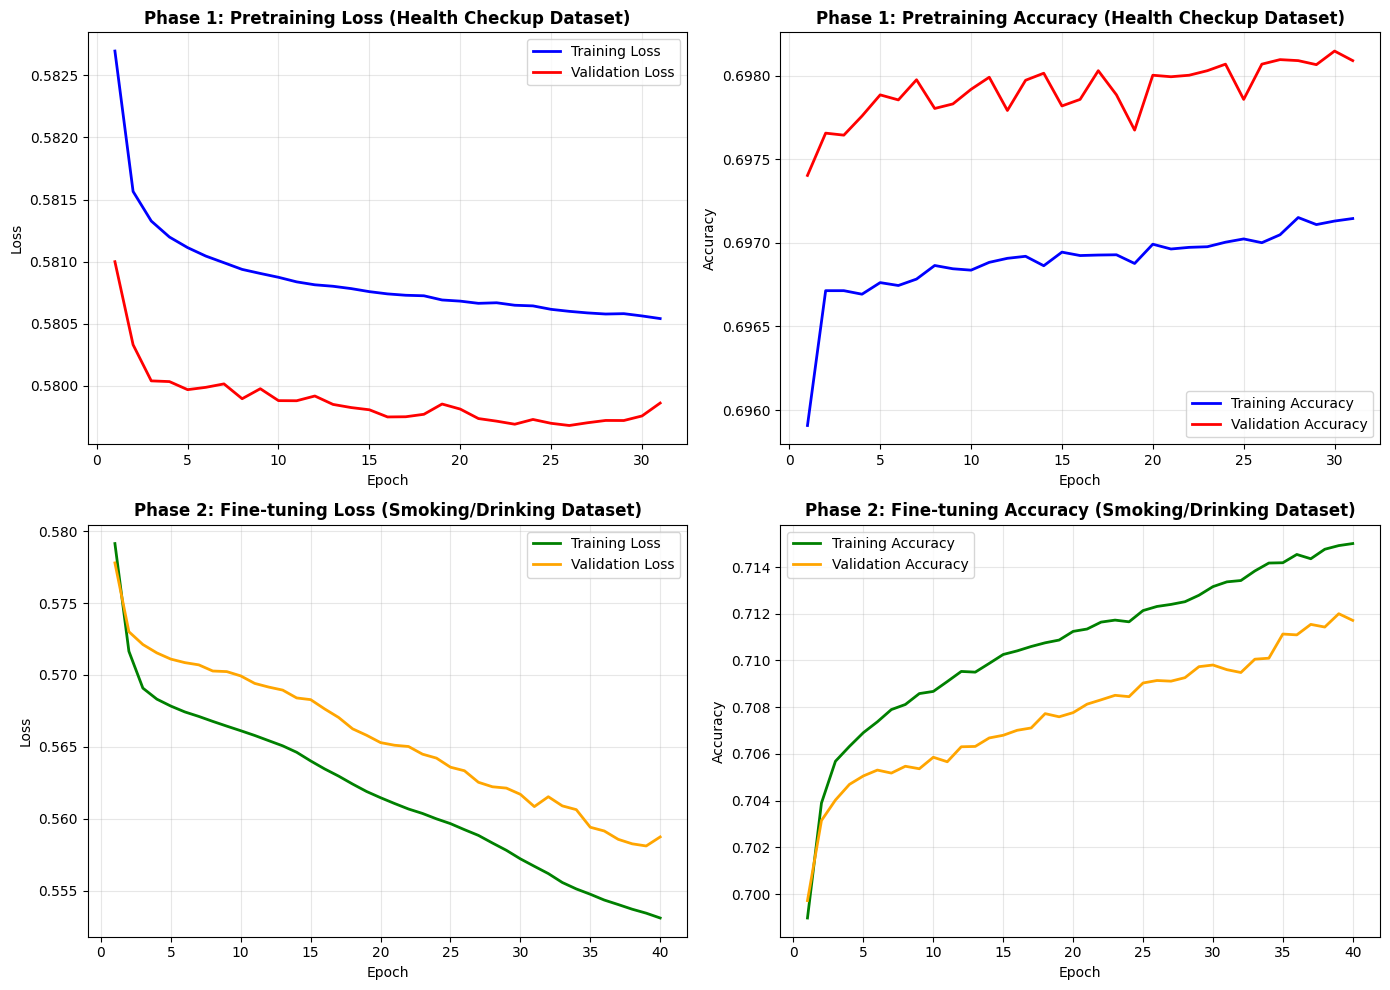


📊 Training Summary:
   Pretraining: 31 epochs on 1328643 samples
   Fine-tuning: 40 epochs on 701614 samples


In [342]:
# === Step 5: Plot training curves for both phases ===
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Pretraining phase plots
pretrain_epochs = range(1, len(pretrain_history.history['loss']) + 1)

# Loss - Pretraining
axes[0, 0].plot(pretrain_epochs, pretrain_history.history['loss'], 'b-', label='Training Loss', linewidth=2)
axes[0, 0].plot(pretrain_epochs, pretrain_history.history['val_loss'], 'r-', label='Validation Loss', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Phase 1: Pretraining Loss (Health Checkup Dataset)', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
# # Set y-axis limits to zoom in very tight on the loss data
# loss_min = min(min(pretrain_history.history['loss']), min(pretrain_history.history['val_loss']))
# loss_max = max(max(pretrain_history.history['loss']), max(pretrain_history.history['val_loss']))
# axes[0, 0].set_ylim([loss_min * 0.98, loss_max * 1.02])


# Accuracy - Pretraining
axes[0, 1].plot(pretrain_epochs, pretrain_history.history['accuracy'], 'b-', label='Training Accuracy', linewidth=2)
axes[0, 1].plot(pretrain_epochs, pretrain_history.history['val_accuracy'], 'r-', label='Validation Accuracy', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Phase 1: Pretraining Accuracy (Health Checkup Dataset)', fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
# # Set y-axis limits to zoom in on the accuracy data
# acc_min = min(min(pretrain_history.history['accuracy']), min(pretrain_history.history['val_accuracy']))
# acc_max = max(max(pretrain_history.history['accuracy']), max(pretrain_history.history['val_accuracy']))
# axes[0, 1].set_ylim([acc_min * 0.98, min(acc_max * 1.02, 1.0)])


# Fine-tuning phase plots
finetune_epochs = range(1, len(finetune_history.history['loss']) + 1)

# Loss - Fine-tuning
axes[1, 0].plot(finetune_epochs, finetune_history.history['loss'], 'g-', label='Training Loss', linewidth=2)
axes[1, 0].plot(finetune_epochs, finetune_history.history['val_loss'], 'orange', label='Validation Loss', linewidth=2)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].set_title('Phase 2: Fine-tuning Loss (Smoking/Drinking Dataset)', fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
# # Set y-axis limits to zoom in very tight on the loss data
# loss_min = min(min(finetune_history.history['loss']), min(finetune_history.history['val_loss']))
# loss_max = max(max(finetune_history.history['loss']), max(finetune_history.history['val_loss']))
# axes[1, 0].set_ylim([loss_min * 0.98, loss_max * 1.02])

# Accuracy - Fine-tuning
axes[1, 1].plot(finetune_epochs, finetune_history.history['accuracy'], 'g-', label='Training Accuracy', linewidth=2)
axes[1, 1].plot(finetune_epochs, finetune_history.history['val_accuracy'], 'orange', label='Validation Accuracy', linewidth=2)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].set_title('Phase 2: Fine-tuning Accuracy (Smoking/Drinking Dataset)', fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
# # Set y-axis limits to zoom in on the accuracy data
# acc_min = min(min(finetune_history.history['accuracy']), min(finetune_history.history['val_accuracy']))
# acc_max = max(max(finetune_history.history['accuracy']), max(finetune_history.history['val_accuracy']))
# axes[1, 1].set_ylim([acc_min * 0.98, min(acc_max * 1.02, 1.0)])

plt.tight_layout()
plt.show()

print(f"\n📊 Training Summary:")
print(f"   Pretraining: {len(pretrain_epochs)} epochs on {len(X_transfer_train)} samples")
print(f"   Fine-tuning: {len(finetune_epochs)} epochs on {len(X_finetune)} samples")

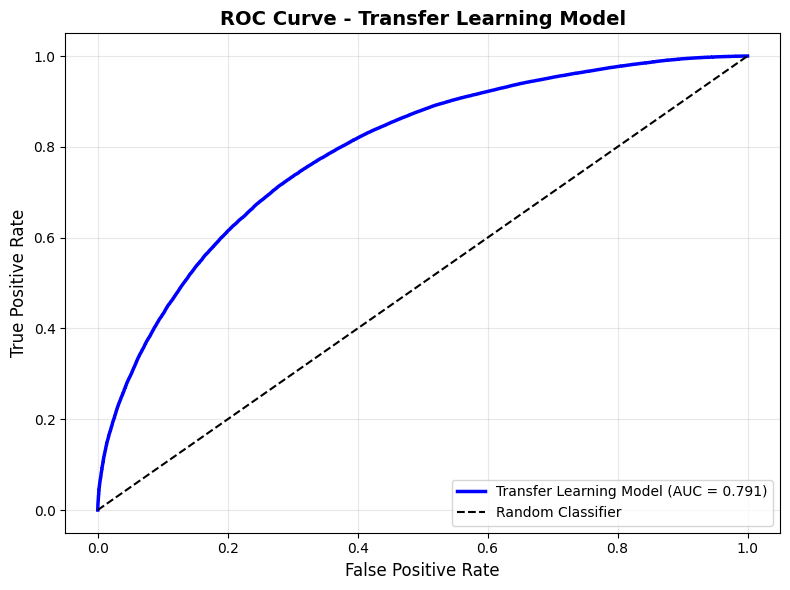


Transfer Learning implementation complete!


In [344]:
# === Step 6: Plot ROC curve ===
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, transfer_prob)
auc_val = roc_auc_score(y_test, transfer_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, 'b-', linewidth=2.5, label=f'Transfer Learning Model (AUC = {auc_val:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Classifier')

# Mark operating point at threshold 0.5
tn, fp, fn, tp = confusion_matrix(y_test, transfer_pred).ravel()
fpr_point = fp / (fp + tn) if (fp + tn) > 0 else 0.0
tpr_point = tp / (tp + fn) if (tp + fn) > 0 else 0.0
# plt.scatter([fpr_point], [tpr_point], s=100, c='red', marker='o', 
#             label=f'Operating Point (T=0.5)\nFPR={fpr_point:.3f}, TPR={tpr_point:.3f}', zorder=5)

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Transfer Learning Model', fontsize=14, fontweight='bold')
plt.legend(fontsize=10, loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nTransfer Learning implementation complete!")